### Necessary Imports

In [1]:
from phenobench import PhenoBench
from pprint import pprint
from phenobench.visualization import draw_semantics

import matplotlib.pyplot as plt
import numpy as np


import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from PIL import Image

import torch
from torch.utils.data import Dataset, TensorDataset, DataLoader 
from phenoBenchWrapper import PhenoBenchWrapper
from torchvision.transforms import ToTensor
import random

seed = 78
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

main_dir='data\PhenoBench-v110\PhenoBench'

### Loading Datasets with PhenoBench

In [2]:
# load training data
train_data = PhenoBench("C:\Malek\Bachelor\BSc\PhenoBench\data\PhenoBench-v110\PhenoBench", 
                        target_types=["semantics"],
                        )

print("Train data loaded")

# load test data
test_data = PhenoBench("C:\Malek\Bachelor\BSc\PhenoBench\data\PhenoBench-v110\PhenoBench", 
                        target_types=["semantics"],
                        split="test")

print("Test data loaded")

# load validation data
val_data = PhenoBench("C:\Malek\Bachelor\BSc\PhenoBench\data\PhenoBench-v110\PhenoBench", 
                        target_types=["semantics"],
                        split="val")
print("Validation data loaded")

print("Train data size: ", len(train_data))
print("Test data size: ", len(test_data))
print("Validation data size: ", len(val_data))



Train data loaded
Test data loaded
Validation data loaded
Train data size:  1407
Test data size:  693
Validation data size:  772


### Load Random Image

Random test image:  {'image_name': 'phenoBench_00105.png', 'image': <PIL.Image.Image image mode=RGB size=1024x1024 at 0x14E022EBCA0>}


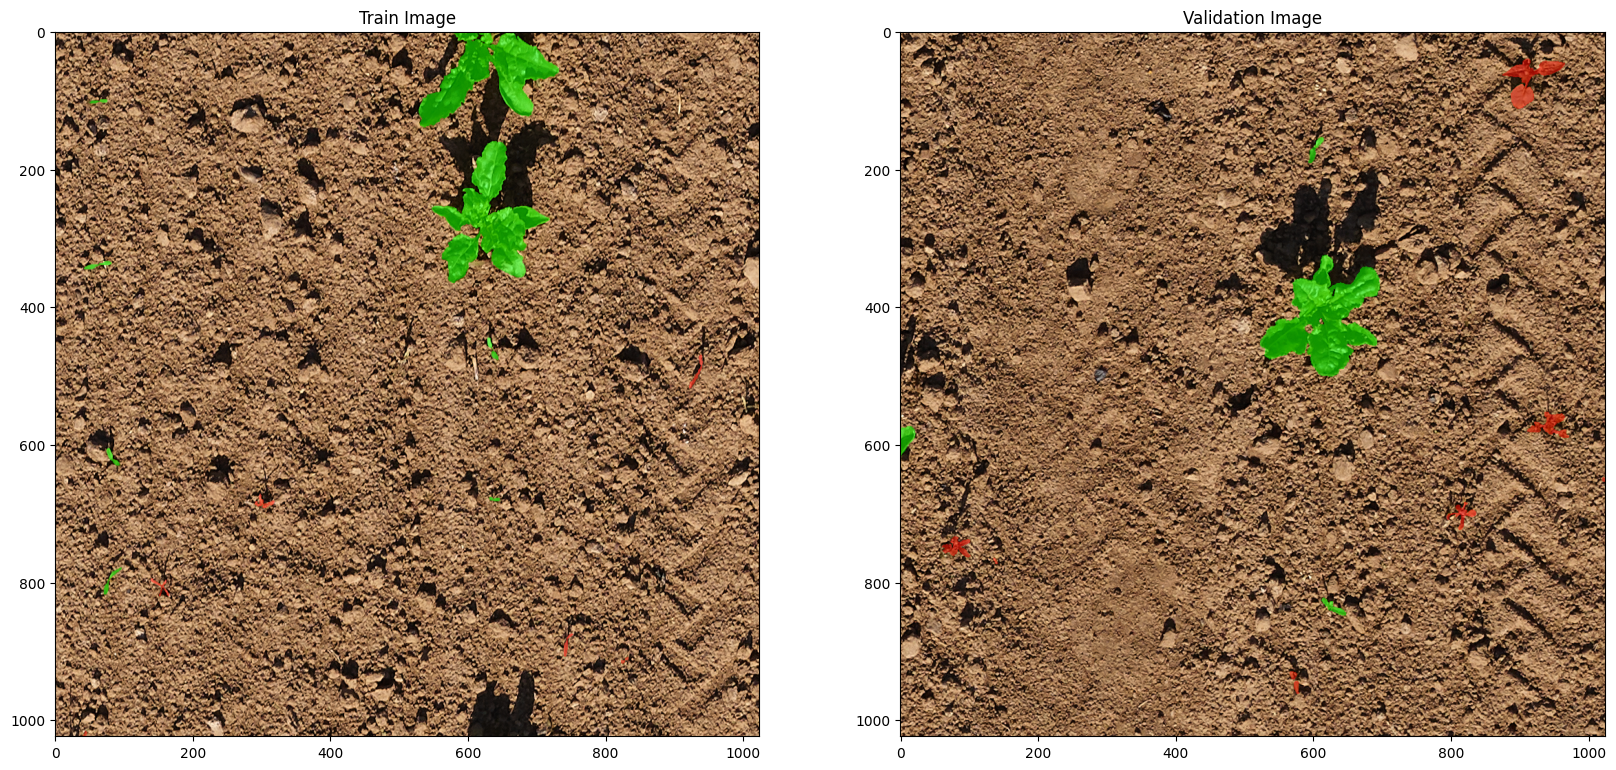

In [3]:
random_test_image=np.random.randint(0, len(test_data))
random_train_image=np.random.randint(0, len(train_data))
random_val_image=np.random.randint(0, len(val_data))

fig,axes=plt.subplots(1,2,figsize=(20,10))
print("Random test image: ", test_data[random_val_image])

# draw the train image
draw_semantics(axes[0],train_data[random_train_image]["image"],train_data[random_train_image]["semantics"])
axes[0].set_title("Train Image")

# draw the validation image
draw_semantics(axes[1],val_data[random_val_image]["image"], val_data[random_val_image]["semantics"])
axes[1].set_title("Validation Image")

plt.show()

In [4]:
print("Random train image: ", train_data[random_train_image].keys())
print("Random train image: ", train_data[random_train_image]["image_name"])
print("Random train image: ", train_data[random_train_image]["image"])
print("Random train image: ", (train_data[random_train_image]["semantics"]==1).sum())

Random train image:  dict_keys(['image_name', 'image', 'semantics'])
Random train image:  05-15_00075_P0030950.png
Random train image:  <PIL.Image.Image image mode=RGB size=1024x1024 at 0x14E0218F880>
Random train image:  27496


### Create Datasets & Dataloaders 

In [20]:

#create train data loader
wrapped_dataset = PhenoBenchWrapper(train_data,split="train")
train_loader = DataLoader(wrapped_dataset, batch_size=8, shuffle=True)
train_sample=next(iter(train_loader))
print("Train data loader created")
print("Train data loader size: ", len(train_loader))
print("Train data loader shape: ")
print(" -sample[0] (image_name): [", len(train_sample[0]),"]")
print(" -sample[1] (image): ",train_sample[1].shape)
print(" -sample[2] (semantics): ",train_sample[2].shape)

print("=========================")

# create test data loader
wrapped_dataset = PhenoBenchWrapper(test_data,split="test")
test_loader = DataLoader(wrapped_dataset, batch_size=8, shuffle=True)
print("Test data loader created")
print("Test data loader size: ", len(test_loader))
print("Test data loader shape: ")
print(" -sample[0] (image_name): [", len(train_sample[0]),"]")
print(" -sample[1] (image): ",train_sample[1].shape)

print("=========================")

# create validation data loader
wrapped_dataset = PhenoBenchWrapper(val_data,split="val")
val_loader = DataLoader(wrapped_dataset, batch_size=8, shuffle=True)
print("Validation data loader created")
print("Validation data loader size: ", len(val_loader))
print("Validation data loader shape: ")
print(" -sample[0] (image_name): [", len(train_sample[0]),"]")
print(" -sample[1] (image): ",train_sample[1].shape)
print(" -sample[2] (semantics): ",train_sample[2].shape)

print("=========================")


Train data loader created
Train data loader size:  176
Train data loader shape: 
 -sample[0] (image_name): [ 8 ]
 -sample[1] (image):  torch.Size([8, 3, 1024, 1024])
 -sample[2] (semantics):  torch.Size([8, 1024, 1024])
Test data loader created
Test data loader size:  87
Test data loader shape: 
 -sample[0] (image_name): [ 8 ]
 -sample[1] (image):  torch.Size([8, 3, 1024, 1024])
Validation data loader created
Validation data loader size:  97
Validation data loader shape: 
 -sample[0] (image_name): [ 8 ]
 -sample[1] (image):  torch.Size([8, 3, 1024, 1024])
 -sample[2] (semantics):  torch.Size([8, 1024, 1024])
